# Simulating data to build a stationary electricity model

In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import python libraries and kind framework --!

import numpy as np
from matplotlib import pyplot as plt

import utils_data

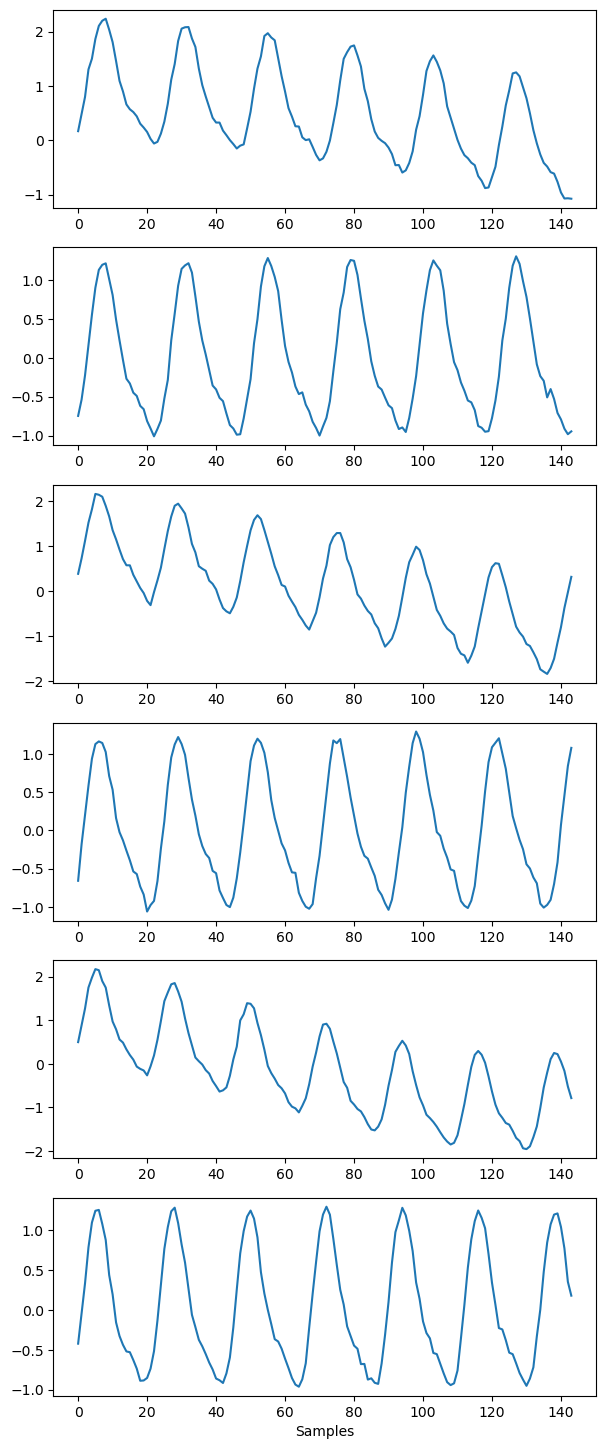

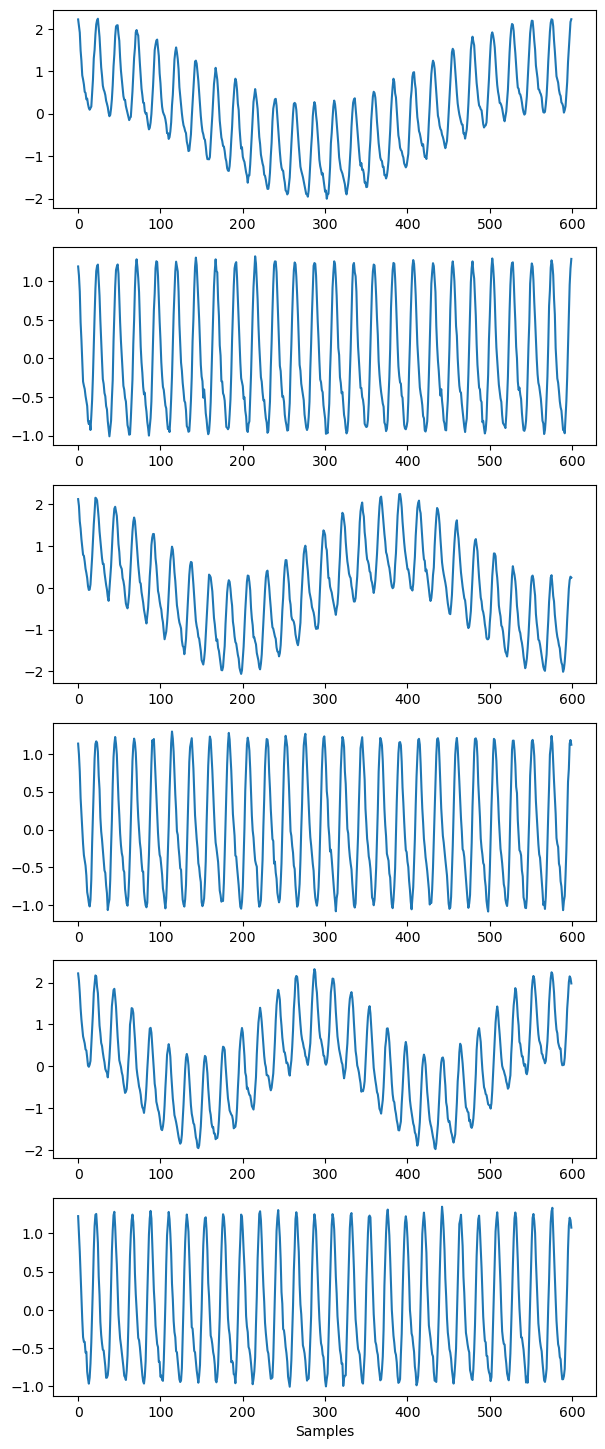

In [6]:
def sample_harm(t, f, a, a0, ns):
    u = np.stack([a0 * np.cos(2 * np.pi * f * t + a) for f, a, a0 in zip(f, a, a0)], axis=-1)
    u = np.sum(u, axis=-1, keepdims=True)
    u = u + np.random.normal(0, ns, size=u.shape)

    return u

t  = np.linspace(0, 52, 600)
ns = 0.04

sim_param = [
    # --! data combination 1 --!
    {
        'f'  : np.array([0.48, 0.96, 0.02]),
        'a'  : np.array([0, np.pi/4, 0]),
        'a0' : np.array([1.0, 0.3, 1.0]),
    },
    {
        'f'  : np.array([0.48, 0.96]),
        'a'  : np.array([0, np.pi/4]),
        'a0' : np.array([1.0, 0.3]),
    },
    # --! data combination 2 --!
    {
        'f'  : np.array([0.5, 1.0, 0.03]),
        'a'  : np.array([0, np.pi/3, 0]),
        'a0' : np.array([1.0, 0.3, 1.0]),
    },
    {
        'f'  : np.array([0.5, 1.0]),
        'a'  : np.array([0, np.pi/3]),
        'a0' : np.array([1.0, 0.3]),
    },
    # --! data combination 2 --!
    {
        'f'  : np.array([0.52, 1.04, 0.04]),
        'a'  : np.array([0, np.pi/4, 0]),
        'a0' : np.array([1.0, 0.3, 1.0]),
    },
    {
        'f'  : np.array([0.52, 1.04]),
        'a'  : np.array([0, np.pi/4]),
        'a0' : np.array([1.0, 0.3]),
    },
]

u = [sample_harm(t, p['f'], p['a'], p['a0'], ns) for p in sim_param]

w  = 7
h  = 3
nu = len(u)

plt.figure(figsize=(w, nu*h))
for j, d in enumerate(u):
    plt.subplot(nu, 1, j + 1)
    plt.plot(d[16:160])
    if j==nu-1:
        plt.xlabel('Samples')
plt.show()

plt.figure(figsize=(w, nu*h))
for j, d in enumerate(u):
    plt.subplot(nu, 1, j + 1)
    plt.plot(d)
    if j==nu-1:
        plt.xlabel('Samples')
plt.show()

In [3]:
datasaved=True

if datasaved:
    savedata     = u
    savedir      = '../../data/baselines/et_train_filter'
    data_nsample = 144
    utils_data.save_traindata(savedata, savedir, data_nsample)

inf >> training files saved
